In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

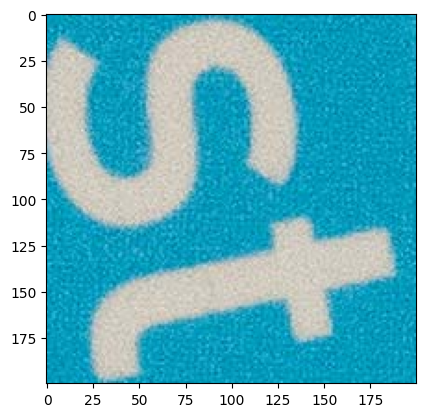

In [18]:
isoRGB = cv2.imread('iso6400raw.jpg', cv2.IMREAD_COLOR_RGB)
iso_gray = cv2.imread('iso6400raw.jpg', cv2.IMREAD_GRAYSCALE)

plt.imshow(isoRGB)

In [19]:
def filter_citra(img, size, mode):
    height, width = img.shape
    pad = size // 2
    padded = np.pad(img, pad, mode='edge')
    canvas = np.zeros_like(img, dtype=np.uint8)

    if mode == 'mean':
        area = size * size
        for i in range(height):
            for j in range(width):
                region = padded[i:i+size, j:j+size]
                total_sum = 0
                for row in region:
                    for pixel in row:
                        total_sum += int(pixel)
                canvas[i, j] = total_sum // area

    elif mode == 'median':
        for i in range(height):
            for j in range(width):
                region = padded[i:i+size, j:j+size]
                values = []
                for row in region:
                    for val in row:
                        values.append(val)
                n = len(values)
                for a in range(n):
                    for b in range(0, n - a - 1):
                        if values[b] > values[b + 1]:
                            values[b], values[b + 1] = values[b + 1], values[b]
                mid = n // 2
                if n % 2 == 0:
                    canvas[i, j] = (values[mid - 1] + values[mid]) // 2
                else:
                    canvas[i, j] = values[mid]

    elif mode == 'modus':
        for i in range(height):
            for j in range(width):
                region = padded[i:i+size, j:j+size]
                values = region.ravel()
                count = {}
                for val in values:
                    if val in count:
                        count[val] += 1
                    else:
                        count[val] = 1
                max_count = 0
                mode_val = 0
                for val, freq in count.items():
                    if freq > max_count:
                        max_count = freq
                        mode_val = val
                canvas[i, j] = mode_val

    return canvas


In [20]:
def convolution(img, kernel):
    size = kernel.shape[0]
    pad_size = size // 2
    padded = np.pad(img, pad_size, mode='constant')

    canvas = np.zeros_like(img).astype(np.float32)
    height, width = img.shape
    
    for i in range(height):
        for j in range(width):
            region = padded[i:i+size, j:j+size]
            canvas[i, j] = np.sum(region * kernel)
    return canvas

def edge_detection(img, kernelx, kernely):
    gx = convolution(img, kernelx)
    gy = convolution(img, kernely)
    
    canvas = np.abs(gx) + np.abs(gy)
    
    if np.max(canvas) != 0:
        canvas = (canvas * 255.0) / np.max(canvas)
    return np.clip(canvas, 0, 255).astype(np.uint8)


In [114]:
sobelx = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
], dtype=np.float32)

sobely = np.array([
    [ 1,  2,  1],
    [ 0,  0,  0],
    [-1, -2, -1]
], dtype=np.float32)

kernel = np.array([
    [0,0,1,1,1],
    [0,0,1,1,1],
    [1,1,1,1,1],
    [1,1,1,0,0],
    [1,1,1,0,0],
], dtype=np.uint8)

In [23]:
def thresholding(image, angka):
    h, w = image.shape
    hasil = np.zeros((h,w), dtype=image.dtype)

    for x in range(h):
        for y in range(w):
            if(image[x,y] >= angka):
                hasil[x,y] = 255
            else:
                hasil[x,y] = 0
    return hasil

In [107]:
isogray_median = filter_citra(iso_gray, 13, 'median')


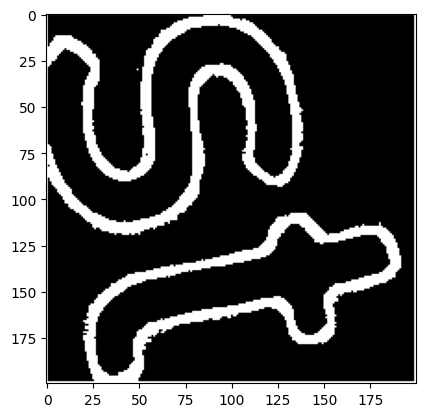

In [110]:
iso_detect = edge_detection(isogray_median, sobelx, sobely)
iso_fix = thresholding(iso_detect, 15)

plt.imshow(iso_fix, cmap= 'gray')

In [ ]:
def dilation(img, kernel):

    h,w = img.shape
    kh,kw = kernel.shape

    pad_h = kh//2
    pad_w = kw//2

    result = np.zeros((h,w), dtype=np.uint8)

    for i in range(pad_h, h-pad_h):

        for j in range(pad_w, w-pad_w):

            isi = False

            for ki in range(kh):

                for kj in range(kw):

                    if kernel[ki,kj] == 1:

                        x = i + ki - pad_h
                        y = j + kj - pad_w

                        if img[x,y] == 255:
                            isi = True

            if isi:
                result[i,j] = 255

    return result


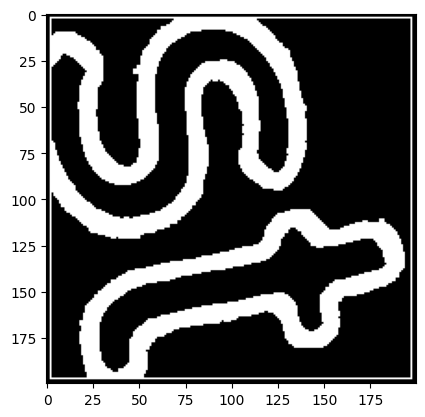

In [111]:
iso_dilasi = dilation(iso_fix, kernel)

plt.imshow(iso_dilasi, cmap= 'gray')

In [59]:
def erosion(img, kernel):

    h, w = img.shape
    kh, kw = kernel.shape

    pad_h = kh // 2
    pad_w = kw // 2

    result = np.zeros((h,w), dtype=np.uint8)

    for i in range(pad_h, h-pad_h):

        for j in range(pad_w, w-pad_w):

            cocok = True

            for ki in range(kh):

                for kj in range(kw):

                    if kernel[ki,kj] == 1:

                        x = i + ki - pad_h
                        y = j + kj - pad_w

                        if img[x,y] == 0:
                            cocok = False

            if cocok:
                result[i,j] = 255

    return result

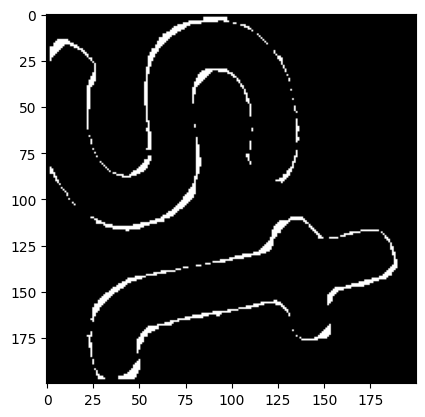

In [112]:
iso_erosi = erosion(iso_fix, kernel)

plt.imshow(iso_erosi, cmap= 'gray')

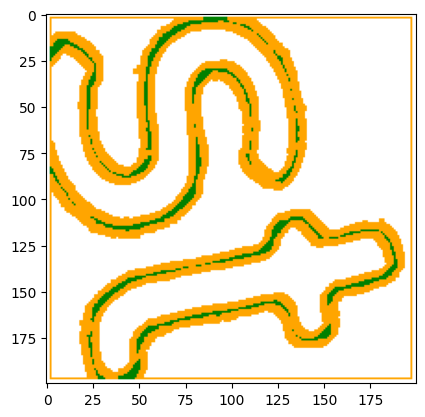

In [ ]:
h, w = iso_dilasi.shape
result = np.ones((h, w, 3), dtype=np.uint8) * 255

result[iso_dilasi == 255] = [255, 165, 0]
result[iso_erosi == 255] = [0, 128, 0]

plt.imshow(result)